# Airbnb Market Analysis – Bologna
**Objective:** Understand key drivers of price, occupancy patterns, and seasonal demand in Bologna Airbnb listings to provide actionable recommendations.

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from geopy.distance import geodesic

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 1. Data Cleaning & Preprocessing
- Removed unnecessary columns.
- Dropped invalid listings with missing prices or invalid room types.
- Filled missing values for `reviews_per_month` and `host_name`.
- Converted `last_review` to datetime.
- Removed extreme outliers in `price` using IQR method.

In [38]:
df = pd.read_csv("../data/listings.csv")
df_clean = df.copy()

# Drop unnecessary columns & invalid listings
df_clean = df_clean.drop(columns=['neighbourhood_group'])
df_clean = df_clean.dropna(subset=['price'])
df_clean = df_clean[df_clean['room_type'] != 0]

# Fill missing values
df_clean['reviews_per_month'] = df_clean['reviews_per_month'].fillna(0)
df_clean['host_name'] = df_clean['host_name'].fillna('Unknown')
df_clean['last_review'] = pd.to_datetime(df_clean['last_review'], errors='coerce')

# Remove price outliers
Q1 = df_clean['price'].quantile(0.25)
Q3 = df_clean['price'].quantile(0.75)
IQR = Q3 - Q1
df_clean = df_clean[df_clean['price'] <= Q3 + 1.5*IQR]


## 2. Feature Engineering
- Log-transformed price to reduce skewness.
- Created `host_type` to distinguish professional hosts.
- Categorized occupancy levels (`low`, `medium`, `high`) based on availability.
- Bucketed reviews per month.
- Calculated distance from Bologna city center.
- Extracted last review month and season.
- Categorized minimum nights.

In [39]:

# Log-transform price
df_clean['price_log'] = np.log1p(df_clean['price'])

# Host professionalism
df_clean['host_type'] = np.where(df_clean['calculated_host_listings_count']>2, 'professional', 'single-listing')

# Occupancy & review buckets
df_clean['occupancy_level'] = pd.qcut(df_clean['availability_365'], 3, labels=['low','medium','high'])
df_clean['reviews_per_month_bucket'] = pd.qcut(df_clean['reviews_per_month'], 3, labels=['low','medium','high'])

# Distance from Bologna city center
city_center = (44.494887, 11.342616)
df_clean['distance_center_km'] = df_clean.apply(
    lambda x: geodesic((x['latitude'], x['longitude']), city_center).km, axis=1
)

# Last review month & season
df_clean['review_month'] = df_clean['last_review'].dt.month
def map_season(month):
    if month in [12,1,2]: return 'winter'
    elif month in [3,4,5]: return 'spring'
    elif month in [6,7,8]: return 'summer'
    elif month in [9,10,11]: return 'fall'
    else: return np.nan
df_clean['review_season'] = df_clean['review_month'].apply(map_season)

# Minimum nights category
df_clean['min_nights_category'] = pd.cut(df_clean['minimum_nights'],
                                         bins=[2,20,50,180,np.inf],
                                         labels=['very short','short','medium','long'])


## 3. Key Analysis & Insights

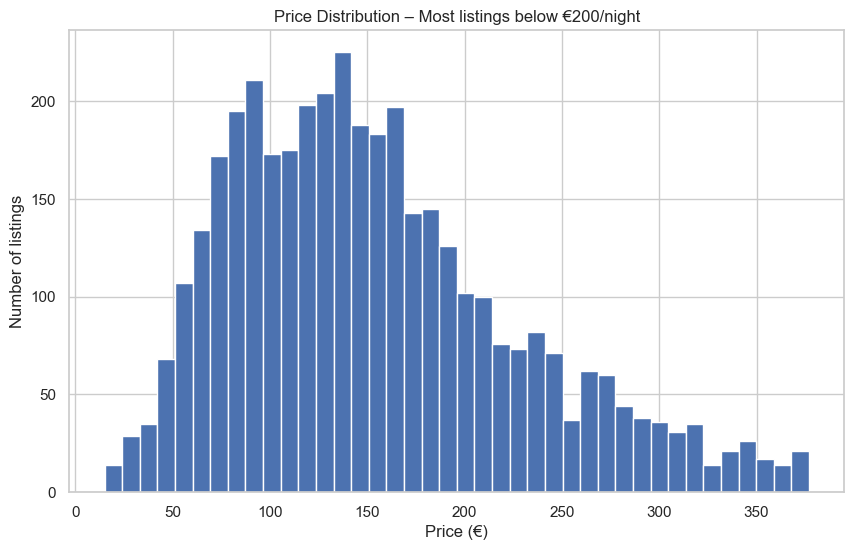

In [40]:
# Price Distribution
plt.hist(df_clean['price'], bins=40)
plt.xlabel("Price (€)")
plt.ylabel("Number of listings")
plt.title("Price Distribution – Most listings below €200/night")
plt.show()


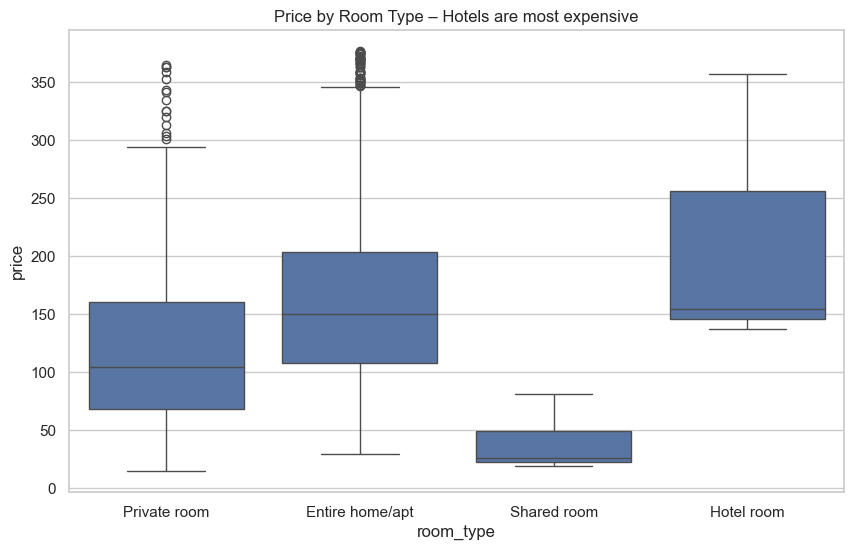

In [41]:
# Price by Room Type
sns.boxplot(x='room_type', y='price', data=df_clean)
plt.title("Price by Room Type – Hotels are most expensive")
plt.show()


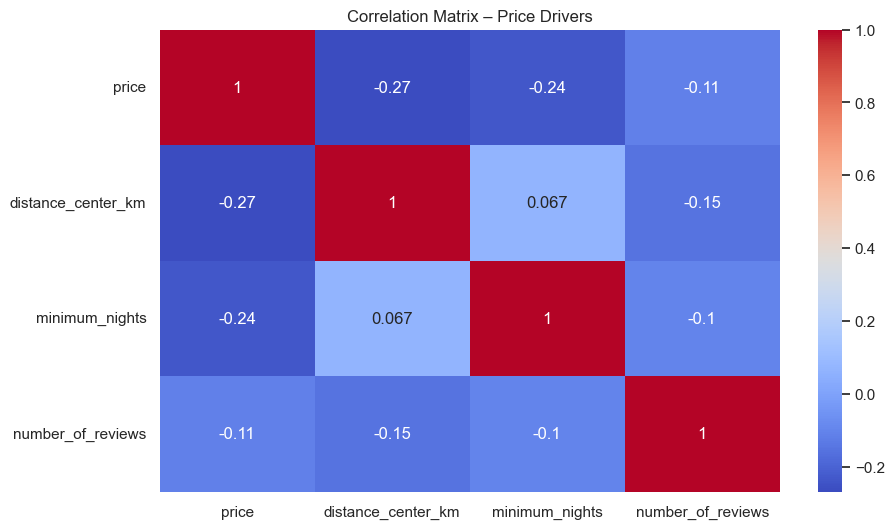

In [42]:
# Key Drivers of Price
price_corr = df_clean[['price','distance_center_km','minimum_nights','number_of_reviews']].corr()
sns.heatmap(price_corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix – Price Drivers")
plt.show()


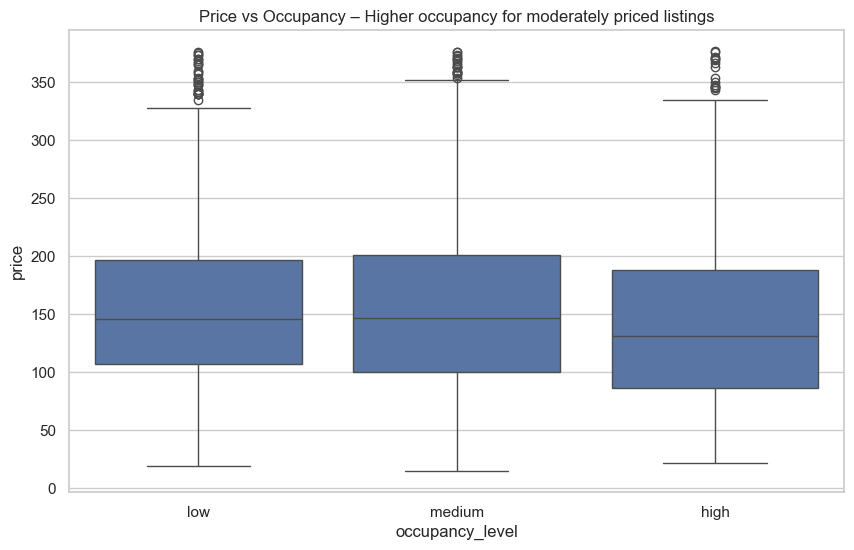

In [43]:

# Occupancy Analysis
sns.boxplot(x='occupancy_level', y='price', data=df_clean)
plt.title("Price vs Occupancy – Higher occupancy for moderately priced listings")
plt.show()


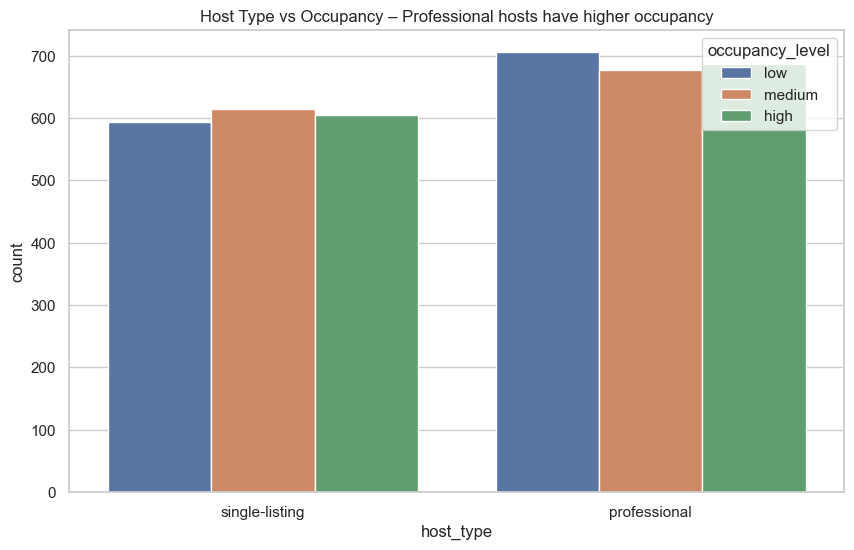

In [44]:

sns.countplot(x='host_type', hue='occupancy_level', data=df_clean)
plt.title("Host Type vs Occupancy – Professional hosts have higher occupancy")
plt.show()


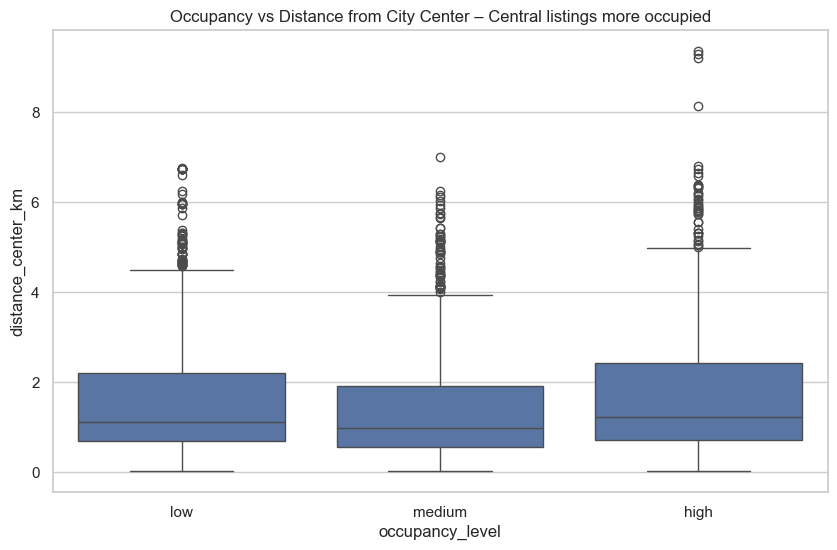

In [45]:

# Location & Seasonality
sns.boxplot(x='occupancy_level', y='distance_center_km', data=df_clean)
plt.title("Occupancy vs Distance from City Center – Central listings more occupied")
plt.show()


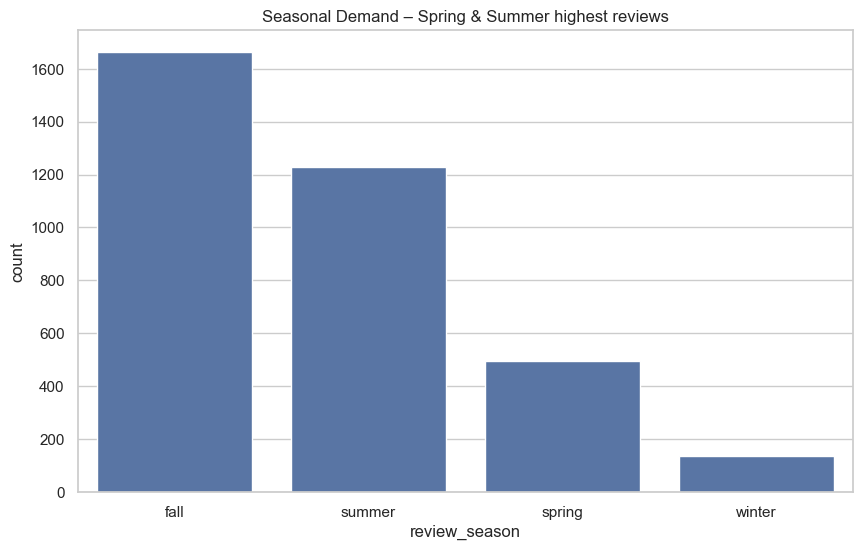

In [46]:

sns.countplot(x='review_season', data=df_clean)
plt.title("Seasonal Demand – Spring & Summer highest reviews")
plt.show()


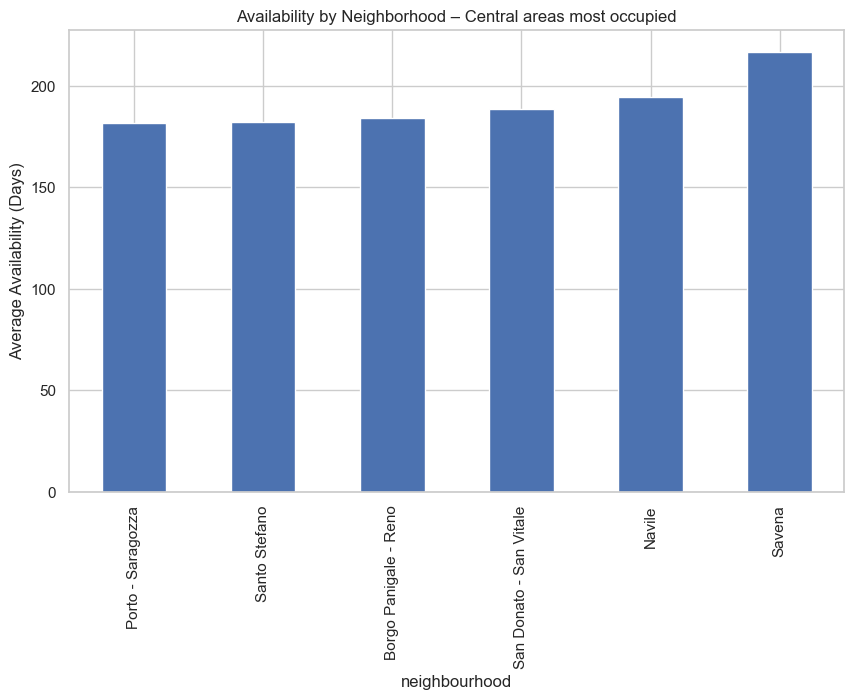

In [47]:
# Neighborhood Insights
neigh_occ = df_clean.groupby('neighbourhood')['availability_365'].mean().sort_values()
neigh_occ.plot(kind='bar')
plt.ylabel("Average Availability (Days)")
plt.title("Availability by Neighborhood – Central areas most occupied")
plt.show()


In [48]:
df_clean.to_csv("bologna_airbnb_cleaned_features.csv", index=False)

### 3.1 Insight:
- Most listings are priced below €200 per night, with a few high-price outliers.
- Hotels are the most expensive, followed by entire homes, private rooms, and shared rooms.
- Distance from city center strongly influences price
- Central neighborhoods have higher occupancy and prices.
- Listings closer to the city center are more expensive.
- High-occupancy listings are usually professional hosts with moderate minimum night requirements.
- Reviews peak in spring and summer, indicating seasonal demand.


## 5. Summary & Recommendations

In [49]:

print("Key Insights from Bologna Airbnb Listings\n")

# 1. Price Insights
print("1. Price Drivers:")
print("- Most listings are priced below €200/night; distribution is right-skewed.")
print("- Room type is a strong determinant: hotels > entire homes > private rooms > shared rooms.")
print("- Host professionalism impacts price: professional hosts generally charge higher rates.")
print("- Distance from city center is negatively correlated with price: listings closer to central Bologna are more expensive.\n")

# 2. Occupancy Insights
print("2. Occupancy Patterns:")
print("- High-occupancy listings often have professional hosts and moderate minimum night requirements.")
print("- Occupancy is higher in central neighborhoods and lower for listings located further away from the city center.")
print("- Listings with consistent reviews per month tend to have better occupancy.\n")

# 3. Seasonal & Location Insights
print("3. Seasonality & Location Effects:")
print("- Reviews peak in spring and summer, indicating higher seasonal demand.")
print("- Central neighborhoods show both higher prices and higher occupancy, suggesting location drives demand.")
print("- Peripheral listings may require price adjustments or promotional strategies to improve occupancy.\n")

# 4. Recommendations
print("4. Strategic Recommendations:")
print("- Pricing Strategy: Adjust prices based on room type, host professionalism, and proximity to city center.")
print("- Marketing & Promotion: Focus promotional efforts on off-peak seasons (fall & winter) to stabilize demand.")
print("- Host Support: Encourage single-listing hosts to adopt professional hosting practices (e.g., faster response, quality photos, detailed descriptions) to increase occupancy.")
print("- Minimum Nights: Moderate minimum night requirements may improve occupancy for both central and peripheral listings.")
print("- Feature Optimization: Highlight proximity to popular Bologna landmarks in listings for central areas to justify higher prices.\n")

Key Insights from Bologna Airbnb Listings

1. Price Drivers:
- Most listings are priced below €200/night; distribution is right-skewed.
- Room type is a strong determinant: hotels > entire homes > private rooms > shared rooms.
- Host professionalism impacts price: professional hosts generally charge higher rates.
- Distance from city center is negatively correlated with price: listings closer to central Bologna are more expensive.

2. Occupancy Patterns:
- High-occupancy listings often have professional hosts and moderate minimum night requirements.
- Occupancy is higher in central neighborhoods and lower for listings located further away from the city center.
- Listings with consistent reviews per month tend to have better occupancy.

3. Seasonality & Location Effects:
- Reviews peak in spring and summer, indicating higher seasonal demand.
- Central neighborhoods show both higher prices and higher occupancy, suggesting location drives demand.
- Peripheral listings may require price ad